# Skin Analysis AI Performance EDA: Model Comparison

This notebook provides a comprehensive comparison between **1st_coat** and **1st_cnn** models.

## Comparison Objectives
1. **Architecture Benchmark**: Compare CoAtNet (Hybrid Transformer-CNN) vs Standard CNN performance.
2. **Multi-View Validation**: Confirm if both models benefit from side views (L30/R30).
3. **Error Analysis**: Visualize Correlation, MAE, and Raw Predictions side-by-side.

In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

BASE_DIR = "/home/j-i14a704/work/seunghun/S14P11A704/ai/skin-analysis/NIA/checkpoint"
MODELS_TO_COMPARE = ["1st_coat", "1st_cnn"]

In [18]:
def parse_log_file(file_path):
    """Parses a single summary log file."""
    if not os.path.exists(file_path):
        return []
    with open(file_path, "r") as f:
        lines = f.readlines()
    if len(lines) < 2: return []
    header = [h.strip() for h in lines[0].split(",")]
    data = []
    for line in lines[1:]:
        if not line.strip(): continue
        parts = [p.strip() for p in line.split(",")]
        row = dict(zip(header, parts))
        data.append(row)
    return data

def aggregate_logs_multiple_models(base_dir, model_type, model_versions):
    """Aggregates summary logs from multiple models."""
    aggregated_data = []
    files = {
        "Total": "print_total.txt", "Front": "print_F.txt",
        "Left": "print_L.txt", "Right": "print_R.txt",
        "L30": "print_L30.txt", "R30": "print_R30.txt"
    }
    
    for ver in model_versions:
        sub_path = os.path.join(base_dir, model_type, ver, "log/save-log")
        for label, filename in files.items():
            file_path = os.path.join(sub_path, filename)
            rows = parse_log_file(file_path)
            for row in rows:
                if "Angle" not in row: row["Angle"] = label
                for k, v in row.items():
                    try: row[k] = float(v)
                    except: pass
                row["ModelType"] = model_type
                row["ModelVersion"] = ver
                aggregated_data.append(row)
                
    return pd.DataFrame(aggregated_data)

# Part 1: Model Comparison (Summary Metrics)
Comparison of Classification and Regression performance between the two architectures.

In [19]:
# Load Summaries
class_summary = aggregate_logs_multiple_models(BASE_DIR, "class", MODELS_TO_COMPARE)
reg_summary = aggregate_logs_multiple_models(BASE_DIR, "regression", MODELS_TO_COMPARE)

print(f"Loaded Class Summary: {len(class_summary)} rows")
print(f"Loaded Reg Summary: {len(reg_summary)} rows")

Loaded Class Summary: 96 rows
Loaded Reg Summary: 108 rows


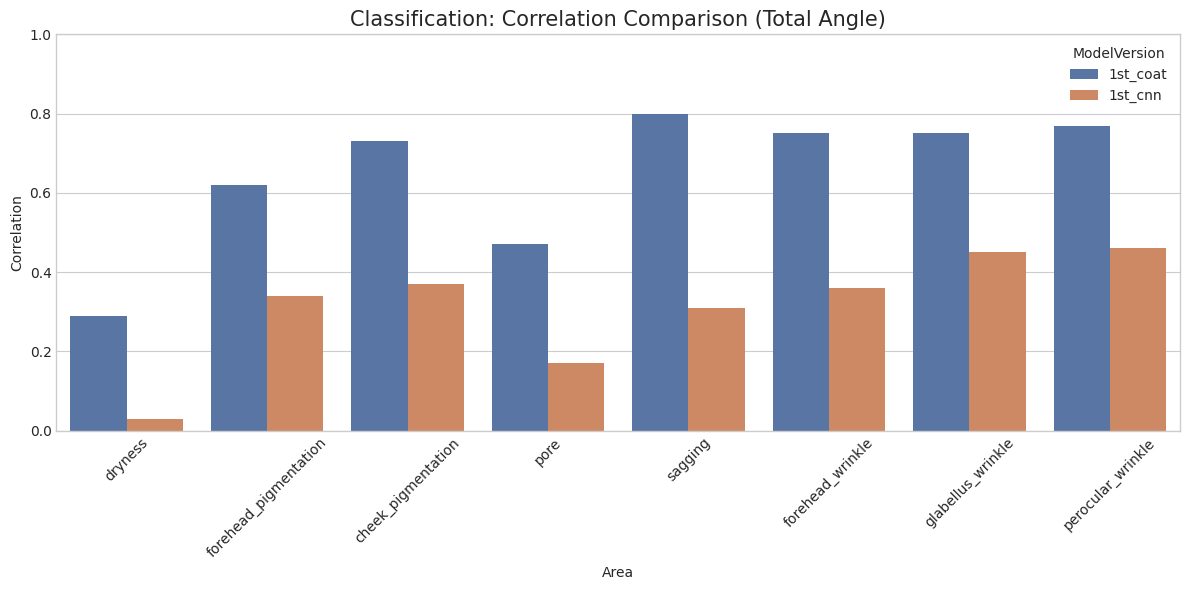

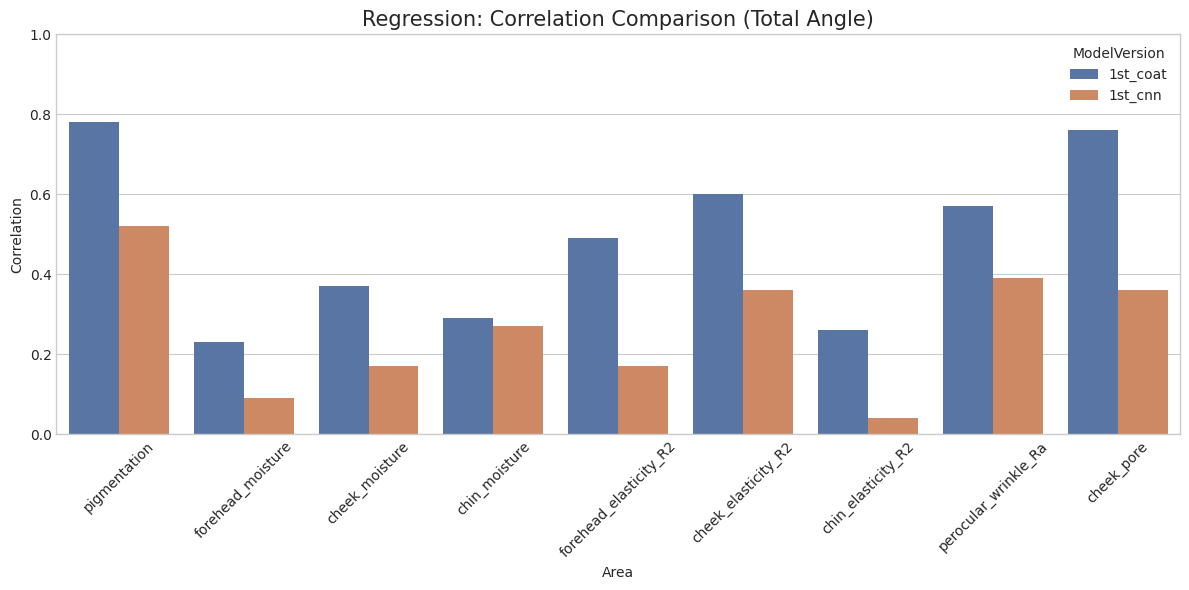

In [20]:
def plot_comparison(df, value_col, title, higher_is_better=True):
    # Filter for Total angle to reduce clutter, or make it interactive?
    # Let's show Total first as general benchmark
    subset = df[df["Angle"] == "Total"]
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=subset, x="Area", y=value_col, hue="ModelVersion", palette="deep")
    plt.title(f"{title} (Total Angle)", fontsize=15)
    plt.xticks(rotation=45)
    if higher_is_better: plt.ylim(0, 1.0)
    plt.tight_layout()
    plt.show()

plot_comparison(class_summary, "Correlation", "Classification: Correlation Comparison")
plot_comparison(reg_summary, "Correlation", "Regression: Correlation Comparison")

### Detailed View: Feature x Angle x Model
Let's zoom into a specific feature to see how models compare across angles.

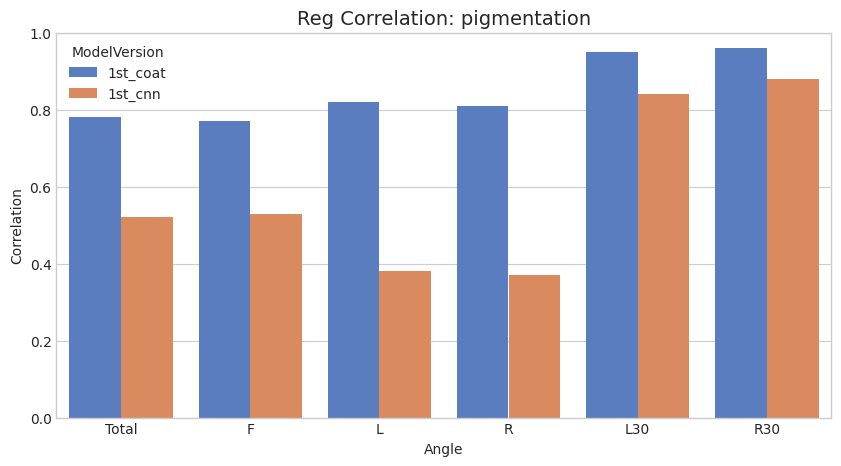

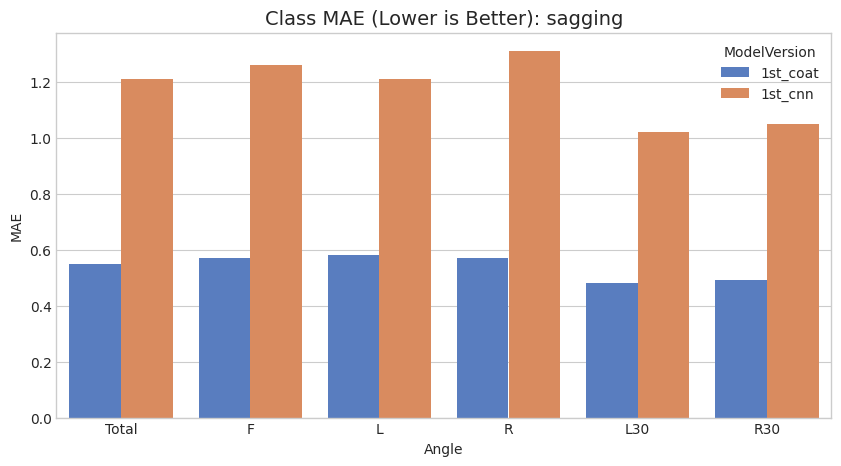

In [21]:
def plot_feature_comparison(df, area_keyword, metric, title_prefix, higher_is_better=True):
    # Find areas containing keyword
    areas = [a for a in df["Area"].unique() if area_keyword in a]
    if not areas: return
    
    target_area = areas[0] # Pick first match
    subset = df[df["Area"] == target_area]
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=subset, x="Angle", y=metric, hue="ModelVersion", palette="muted")
    plt.title(f"{title_prefix}: {target_area}", fontsize=14)
    if higher_is_better: plt.ylim(0, 1.0)
    plt.show()

# Example: Compare Pigmentation (Reg) and Sagging (Class)
plot_feature_comparison(reg_summary, "pigmentation", "Correlation", "Reg Correlation")
plot_feature_comparison(class_summary, "sagging", "MAE", "Class MAE (Lower is Better)", higher_is_better=False)

# Part 2: Detailed Error Analysis (Raw Predictions)
Parsing `gt.txt` and `pred.txt` for both models.

In [22]:
def load_raw_predictions_multi(base_dir, model_type, model_versions):
    combined_list = []
    for ver in model_versions:
        pred_dir = os.path.join(base_dir, model_type, ver, "prediction")
        gt_path = os.path.join(pred_dir, "gt.txt")
        pred_path = os.path.join(pred_dir, "pred.txt")
        
        if not os.path.exists(gt_path): continue
        
        gt = pd.read_csv(gt_path, header=None, names=["Angle", "Area", "GT", "ID"])
        pred = pd.read_csv(pred_path, header=None, names=["Angle", "Area", "Pred", "ID"])
        
        # Simple merge by index, assuming aligned
        temp = gt.copy()
        temp["Pred"] = pred["Pred"]
        temp["ModelVersion"] = ver
        
        # Cleanup
        temp["Area"] = temp["Area"].str.strip()
        temp["Angle"] = temp["Angle"].str.strip()
        combined_list.append(temp)
        
    return pd.concat(combined_list, ignore_index=True) if combined_list else pd.DataFrame()

raw_class = load_raw_predictions_multi(BASE_DIR, "class", MODELS_TO_COMPARE)
raw_reg = load_raw_predictions_multi(BASE_DIR, "regression", MODELS_TO_COMPARE)

print(f"Raw Class Rows: {len(raw_class)}")
print(f"Raw Reg Rows: {len(raw_reg)}")

Raw Class Rows: 31866
Raw Reg Rows: 17936


## 2.1 Regression Scatter Comparison
Directly compare the scatter plots of CoAtNet vs CNN.

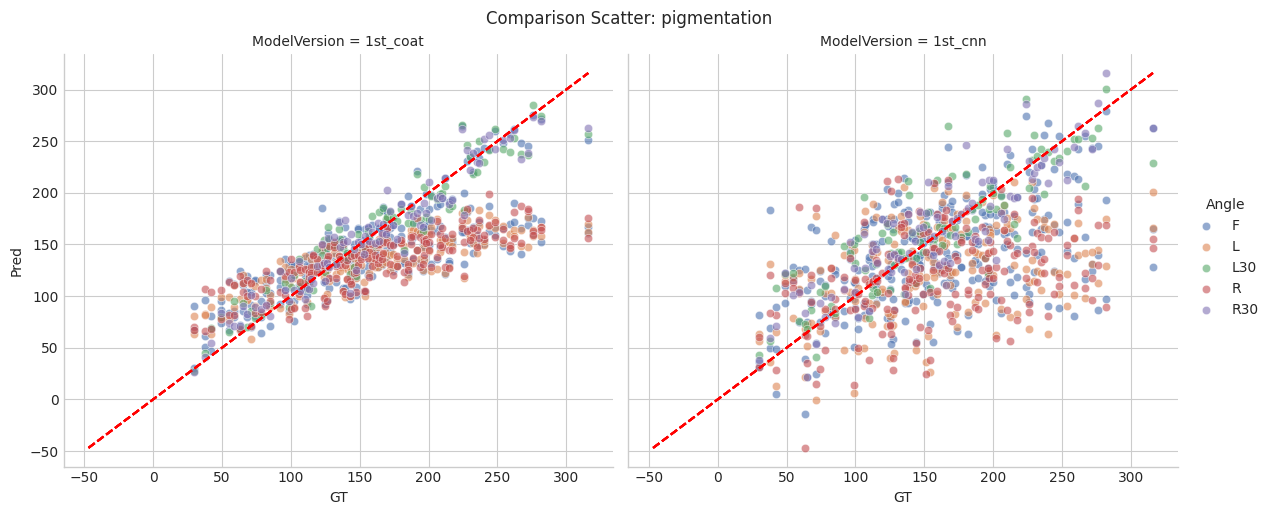

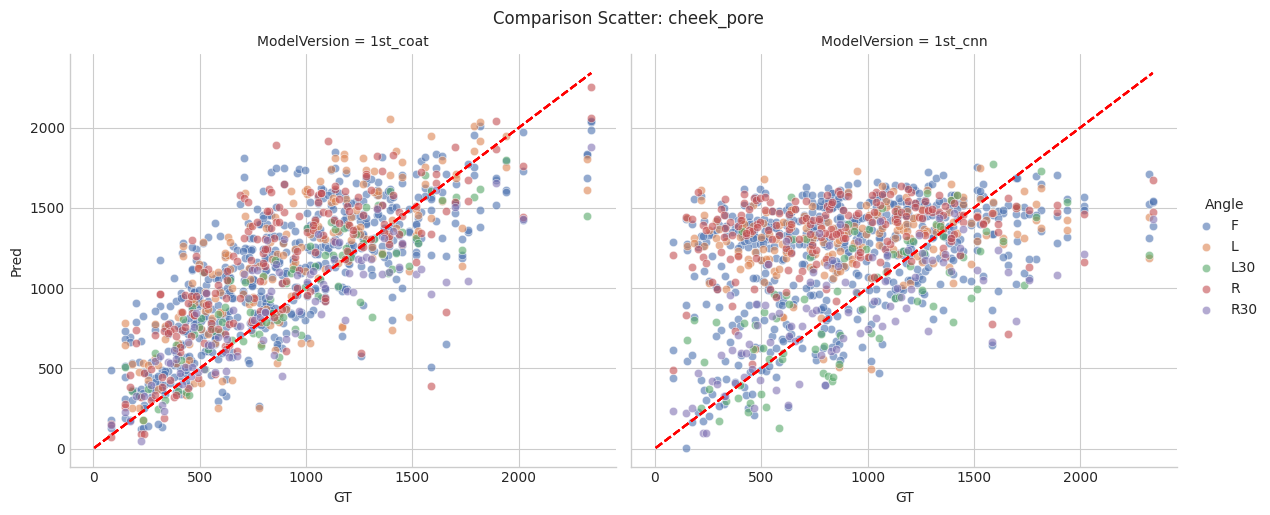

In [23]:
def plot_regression_comparison_scatter(df, area):
    subset = df[df["Area"] == area]
    if len(subset) == 0: return
    
    g = sns.FacetGrid(subset, col="ModelVersion", hue="Angle", height=5, aspect=1.2, palette="deep")
    g.map(sns.scatterplot, "GT", "Pred", alpha=0.6)
    
    # Add ideal line
    min_val = min(subset["GT"].min(), subset["Pred"].min())
    max_val = max(subset["GT"].max(), subset["Pred"].max())
    
    def draw_line(*args, **kwargs):
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5)
        
    g.map(draw_line)
    g.add_legend()
    g.fig.suptitle(f"Comparison Scatter: {area}", y=1.02)
    plt.show()

compare_areas = ["pigmentation", "cheek_pore"]
for area in compare_areas:
    if area in raw_reg["Area"].unique():
        plot_regression_comparison_scatter(raw_reg, area)

## conclusions

- By comparing the bar charts, you can immediately see which model version yields higher correlation bars.
- Faceted scatter plots reveal if one model has a tighter spread along the diagonal line (better precision) than the other.

# Part 2: Detailed Analysis (Raw Predictions)

This section analyzes the raw `pred.txt` and `gt.txt` files to determine **model performance by area** and identify the **optimal angle for each area**.


In [ ]:
import re

def parse_prediction_file(file_path):
    """Parses prediction/ground-truth files to extract metadata."""
    if not os.path.exists(file_path):
        return []
    
    data = []
    # Regex to extract Area from ImageName: e.g., ..._Area_07
    area_pattern = re.compile(r'Area_(\d+)')
    
    with open(file_path, 'r') as f:
        for line in f:
            parts = [p.strip() for p in line.split(',')]
            if len(parts) >= 4:
                # Format: Angle, Task, Value, ImageID
                angle = parts[0]
                task = parts[1]
                try:
                    value = float(parts[2])
                except ValueError:
                    continue
                image_id = parts[3]
                
                # Extract Area
                match = area_pattern.search(image_id)
                area = match.group(1) if match else "Unknown"
                
                data.append({
                    "Angle": angle,
                    "Task": task,
                    "Value": value,
                    "Area": area,
                    "ImageID": image_id
                })
    return pd.DataFrame(data)

def load_model_predictions(base_dir, model_type, model_name):
    """Loads and merges pred and gt files for a model."""
    path = os.path.join(base_dir, model_type, model_name, "prediction")
    pred_path = os.path.join(path, "pred.txt")
    gt_path = os.path.join(path, "gt.txt")
    
    if not os.path.exists(pred_path) or not os.path.exists(gt_path):
        return None
        
    df_pred = parse_prediction_file(pred_path)
    df_gt = parse_prediction_file(gt_path)
    
    if df_pred.empty or df_gt.empty:
        return None
        
    # Rename and Merge
    df_pred = df_pred.rename(columns={"Value": "Pred"})
    df_gt = df_gt.rename(columns={"Value": "GT"})
    
    # Merge on ImageID (and verify Angle/Task/Area matches)
    # Simplify by merging on ImageID
    df = pd.merge(df_pred, df_gt[["ImageID", "GT"]], on="ImageID", how="inner")
    df["ModelType"] = model_type
    df["ModelName"] = model_name
    return df

In [ ]:
# Load All Data
all_data = []
checkpoints = [
    ("class", "1st_cnn"),
    ("class", "1st_coat"),
    ("class", "2st test"),
    ("regression", "1st_cnn"),
    ("regression", "1st_coat")
]

for m_type, m_name in checkpoints:
    df = load_model_predictions(BASE_DIR, m_type, m_name)
    if df is not None:
        all_data.append(df)
        print(f"Loaded {m_name} ({m_type}): {len(df)} samples")

full_df = pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()
full_df.head()

In [ ]:
# Analyze Classification Accuracy: Optimal Angle per Area
class_df = full_df[full_df["ModelType"] == "class"].copy()

if not class_df.empty:
    # Calculate Correct predictions
    class_df["Correct"] = (class_df["Pred"] == class_df["GT"]).astype(int)
    
    # Group by Model, Task, Area, Angle
    acc = class_df.groupby(["ModelName", "Task", "Area", "Angle"])["Correct"].mean().reset_index()
    acc = acc.rename(columns={"Correct": "Accuracy"})
    
    # Find Best Angle for each Area (per Task/Model)
    # We focus on 1st_cnn and 1st_coat
    for model in ["1st_cnn", "1st_coat"]:
        model_acc = acc[acc["ModelName"] == model]
        if model_acc.empty: continue
            
        # Pivot for Heatmap
        # Assuming Task='dryness' or similar. If multiple tasks, we plot per task.
        for task in model_acc["Task"].unique():
            task_data = model_acc[model_acc["Task"] == task]
            pivot_table = task_data.pivot(index="Area", columns="Angle", values="Accuracy")
            
            # Determine Best Angle
            best_angle = task_data.loc[task_data.groupby("Area")["Accuracy"].idxmax()]
            
            print(f"\n--- Optimal Angles: {model} ({task}) ---")
            print(best_angle[["Area", "Angle", "Accuracy"]].sort_values("Area").to_string(index=False))
            
            # Plot Heatmap
            plt.figure(figsize=(10, 6))
            sns.heatmap(pivot_table, annot=True, cmap="RdYlGn", fmt=".2f", cbar_kws={'label': 'Accuracy'})
            plt.title(f"Accuracy by Area & Angle: {model} ({task})")
            plt.show()


In [ ]:
# Analyze Regression MAE (if available)
reg_df = full_df[full_df["ModelType"] == "regression"].copy()

if not reg_df.empty:
    # Calculate Absolute Error
    reg_df["AbsError"] = (reg_df["Pred"] - reg_df["GT"]).abs()
    
    # Group
    mae = reg_df.groupby(["ModelName", "Task", "Area", "Angle"])["AbsError"].mean().reset_index()
    mae = mae.rename(columns={"AbsError": "MAE"})
    
    for model in ["1st_cnn", "1st_coat"]:
        model_mae = mae[mae["ModelName"] == model]
        if model_mae.empty: continue
            
        for task in model_mae["Task"].unique():
            task_data = model_mae[model_mae["Task"] == task]
            pivot_table = task_data.pivot(index="Area", columns="Angle", values="MAE")
            
            # Plot Heatmap (Lower is better, so reverse cmap)
            plt.figure(figsize=(10, 6))
            sns.heatmap(pivot_table, annot=True, cmap="RdYlGn_r", fmt=".3f", cbar_kws={'label': 'MAE'})
            plt.title(f"MAE by Area & Angle: {model} ({task})")
            plt.show()
